In [ ]:
# Pandas and NumPy are for handling data
# sklearn has tools for splitting data and building models
# matplotlib is for plotting graphs
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Step 2: Load the dataset

data = pd.read_csv('/content/qsar-biodeg.csv')

# Look at the first 5 rows to see what the data looks like
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,0,0.000,3.106,2.550,9.002,0,0.960,1.142,0,0,0,1.201,0,0,0,0,1.932,0.011,0,0.000,4.489,0,0,0,0,2.949,1.591,0,7.253,0,0,2
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,0,0.000,2.461,1.393,8.723,1,0.989,1.144,0,0,0,1.104,1,0,0,0,2.214,-0.204,0,0.000,1.542,0,0,0,0,3.315,1.967,0,7.257,0,0,2
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,0,0.000,3.279,2.585,9.110,0,1.009,1.152,0,0,0,1.092,0,0,0,0,1.942,-0.008,0,0.000,4.891,0,0,0,1,3.076,2.417,0,7.601,0,0,2
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,0,0.000,2.100,0.918,6.594,0,1.108,1.167,0,0,0,1.024,0,0,0,0,1.414,1.073,0,8.361,1.333,0,0,0,1,3.046,5.000,0,6.690,0,0,2
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,0,-0.271,3.449,2.753,9.528,2,1.004,1.147,0,0,0,1.137,0,0,0,0,1.985,-0.002,0,10.348,5.588,0,0,0,0,3.351,2.405,0,8.003,0,0,2


Dataset shape: (1055, 42)

Columns info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 42 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1055 non-null   float64
 1   V2      1055 non-null   float64
 2   V3      1055 non-null   int64  
 3   V4      1055 non-null   int64  
 4   V5      1055 non-null   int64  
 5   V6      1055 non-null   int64  
 6   V7      1055 non-null   int64  
 7   V8      1055 non-null   float64
 8   V9      1055 non-null   int64  
 9   V10     1055 non-null   int64  
 10  V11     1055 non-null   int64  
 11  V12     1055 non-null   float64
 12  V13     1055 non-null   float64
 13  V14     1055 non-null   float64
 14  V15     1055 non-null   float64
 15  V16     1055 non-null   int64  
 16  V17     1055 non-null   float64
 17  V18     1055 non-null   float64
 18  V19     1055 non-null   int64  
 19  V20     1055 non-null   int64  
 20  V21     1055 non-null   int64  
 

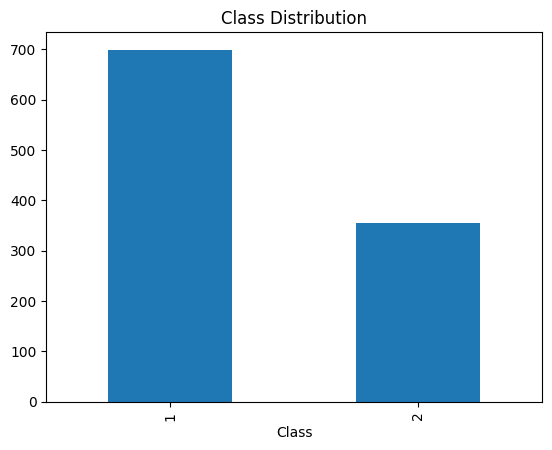

In [ ]:
# Step 3: Check the dataset shape and info
# This tells us how many rows and columns we have, and the type of each column
print("Dataset shape:", data.shape)
print("\nColumns info:")
print(data.info())

# Check if there are any missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Count how many samples are in each class
print("\nClass distribution:")
print(data['Class'].value_counts())

# Make a bar plot of the class distribution
data['Class'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

In [ ]:
# Step 4: Separate features and target
# Features are all columns except 'Class'
X = data.drop('Class', axis=1)

# Target is the 'Class' column
y = data['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1055, 41)
Target shape: (1055,)


In [ ]:
# Step 5: Split data into training and test sets
# 80% of data will be used to train the model, 20% to test it
# stratify=y makes sure both classes are represented equally in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (844, 41)
X_test shape: (211, 41)
y_train shape: (844,)
y_test shape: (211,)


In [ ]:
# Step 6: Train a K-Nearest Neighbors (KNN) model
# Using k=5 neighbors and weighting by distance so closer points matter more
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Fit the model on the training data
knn.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [ ]:
# Step 7: Evaluate the model
# Make predictions on the test set
y_pred = knn.predict(X_test)

# Check overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Show confusion matrix to see correct vs wrong predictions
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed report with precision, recall, and f1-score for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7867298578199052

Confusion Matrix:
 [[115  25]
 [ 20  51]]

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.82      0.84       140
           2       0.67      0.72      0.69        71

    accuracy                           0.79       211
   macro avg       0.76      0.77      0.77       211
weighted avg       0.79      0.79      0.79       211



In [ ]:
# Import necessary modules for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores
cv_scores = cross_val_score(knn, X, y, cv=skf, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

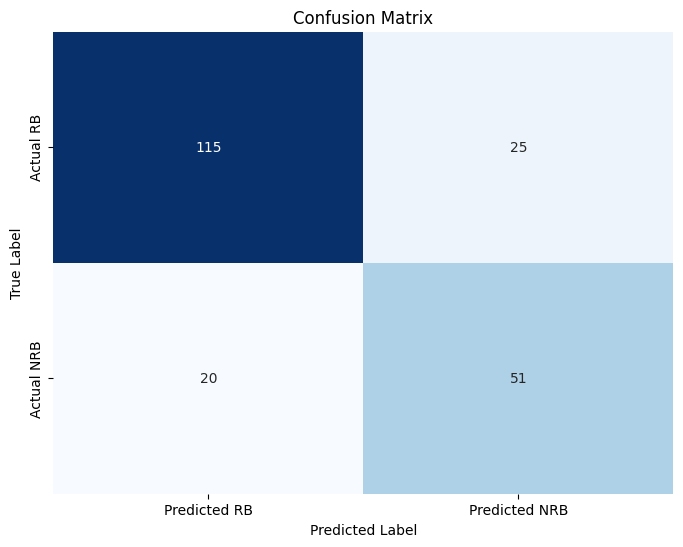

In [ ]:
#Visualization for confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
#cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(np.array([[115,25],[20,51]]), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted RB', 'Predicted NRB'],
            yticklabels=['Actual RB', 'Actual NRB'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7819905213270142

Confusion Matrix:
 [[124  16]
 [ 30  41]]

Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.89      0.84       140
           2       0.72      0.58      0.64        71

    accuracy                           0.78       211
   macro avg       0.76      0.73      0.74       211
weighted avg       0.78      0.78      0.78       211



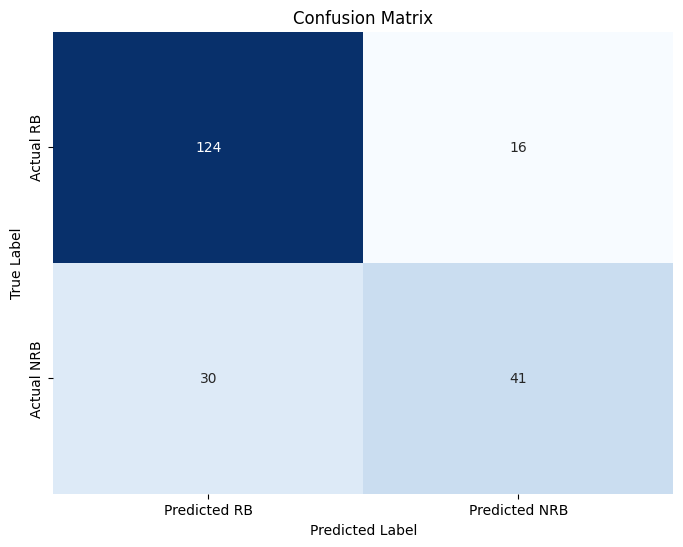

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted RB', 'Predicted NRB'],
            yticklabels=['Actual RB', 'Actual NRB'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Import necessary modules for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores
cv_scores = cross_val_score(svm_model, X, y, cv=skf, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))